# kaggle competitions: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
test_data = pd.read_csv('/Users/raj/Documents/Corpnce AI/practice/kaggle-pricing/house-prices-advanced-regression-techniques/test.csv')
train_data = pd.read_csv('/Users/raj/Documents/Corpnce AI/practice/kaggle-pricing/house-prices-advanced-regression-techniques/train.csv')

In [3]:
len(train_data)

1460

In [4]:
print(train_data.columns)
print(len(train_data.columns))

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
# top 5 columns

train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
# lets find columns with too much data missing

mask = train_data.isnull().sum()[train_data.isnull().sum() > 0]/train_data.shape[0] * 100 > 10

print(len(train_data.columns))
print(mask[mask].index)
train_data = train_data.drop(columns = mask[mask].index)

len(train_data.columns)



81
Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')


74

In [9]:
train_data[train_data['BsmtCond'].isnull()]

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
17,18,90,RL,10791,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,500,10,2006,WD,Normal,90000
39,40,90,RL,6040,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2008,WD,AdjLand,82000
90,91,20,RL,7200,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2006,WD,Normal,109900
102,103,90,RL,7018,Pave,Reg,Bnk,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2009,WD,Alloca,118964
156,157,20,RL,7200,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2006,WD,Normal,109500
182,183,20,RL,9060,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,180,0,0,0,6,2007,WD,Normal,120000
259,260,20,RM,12702,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,97000
342,343,90,RL,8544,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,5,2006,WD,Normal,87500
362,363,85,RL,7301,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,177,0,0,0,0,7,2009,ConLD,Normal,198500
371,372,50,RL,17120,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2008,WD,Normal,134432


In [10]:
train_data.isnull().sum()[train_data.isnull().sum() > 0]/train_data.shape[0] * 100

MasVnrArea      0.547945
BsmtQual        2.534247
BsmtCond        2.534247
BsmtExposure    2.602740
BsmtFinType1    2.534247
BsmtFinType2    2.602740
Electrical      0.068493
GarageType      5.547945
GarageYrBlt     5.547945
GarageFinish    5.547945
GarageQual      5.547945
GarageCond      5.547945
dtype: float64

In [11]:
train_data[train_data["GarageType"].isnull()]

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
39,40,90,RL,6040,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2008,WD,AdjLand,82000
48,49,190,RM,4456,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,102,0,0,0,0,6,2009,New,Partial,113000
78,79,90,RL,10778,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,136500
88,89,50,C (all),8470,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,156,0,0,0,0,10,2009,ConLD,Abnorml,85000
89,90,20,RL,8070,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,123600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349,1350,70,RM,5250,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,20,0,0,0,0,12,2008,WD,Normal,122000
1407,1408,20,RL,8780,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,3,2009,WD,Normal,112000
1449,1450,180,RM,1533,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2006,WD,Abnorml,92000
1450,1451,90,RL,9000,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,9,2009,WD,Normal,136000


In [12]:
train_data['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

In [13]:
# fill emtpy values in all columns

train_data['MasVnrArea'] = train_data['MasVnrArea'].fillna(train_data['MasVnrArea'].median()) # replaced most repeated values with null values
train_data['BsmtQual'] = train_data['BsmtQual'].fillna('None') # replaced with most repeated values with null values
train_data['BsmtCond'] = train_data['BsmtCond'].fillna('None') # same
train_data['BsmtExposure'] = train_data['BsmtExposure'].fillna('None') # same
train_data['BsmtFinType1'] = train_data['BsmtFinType1'].fillna('None') # same
train_data['BsmtFinType2'] = train_data['BsmtFinType2'].fillna('None') # same
train_data['Electrical'] = train_data['Electrical'].fillna('SBrkr') # same
train_data['GarageType'] = train_data['GarageType'].fillna('None') # same
train_data['GarageYrBlt'] = train_data['GarageYrBlt'].fillna(0)
train_data['GarageFinish'] = train_data['GarageFinish'].fillna('None') # same
train_data['GarageQual'] = train_data['GarageQual'].fillna('None') # same
train_data['GarageCond'] = train_data['GarageCond'].fillna('None') # same



In [14]:
# lets check empty columns 
print(f"before = {len(train_data)}")
train_data.isnull().any(axis=1).sum()
train_data = train_data.dropna()
print(f"after = {len(train_data)}")

before = 1460
after = 1460


In [15]:
# convert years to age

train_data['BuiltAge'] = train_data['YrSold']- train_data['YearBuilt']
train_data['RemodAge'] = train_data['YrSold'] - train_data['YearRemodAdd']
train_data['GarageYrAge'] = train_data['YrSold'] - train_data['GarageYrBlt']
# train_data['YrSold'] = train_data['YearBuilt'] - train_data['YrSold']

train_data = train_data.drop(columns=['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'])
train_data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal

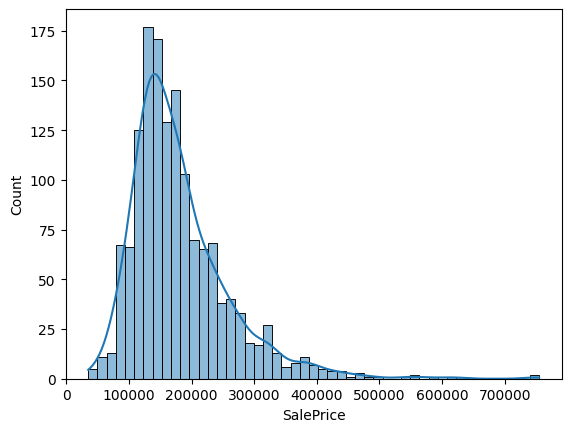

In [16]:
sns.histplot(train_data['SalePrice'], kde=True)
plt.show()

In [17]:
train_data['SalePrice'] = np.log1p(train_data['SalePrice'])
print(train_data['SalePrice'])
# sns.histplot(y_log, kde=True)
# plt.show()

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64


In [18]:
corr = train_data.corr(numeric_only=True)
print(corr['SalePrice'].sort_values(ascending=False))

SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.426776
BsmtFinSF1       0.372023
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
GarageYrAge     -0.349109
RemodAge        -0.568136
BuiltAge        -0.587290
Name: SalePrice, dtype: float64


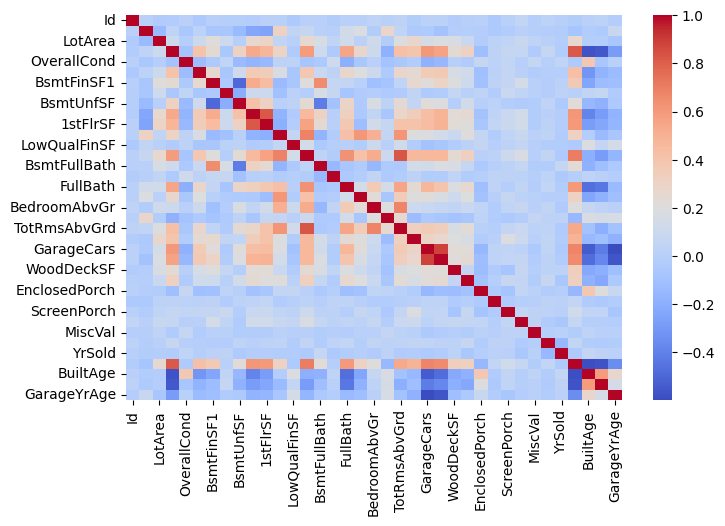

In [19]:
import seaborn as sn
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

In [20]:
top_features = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index
top_features

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'BuiltAge', 'RemodAge',
       'TotRmsAbvGrd', 'Fireplaces', 'MasVnrArea', 'BsmtFinSF1',
       'GarageYrAge'],
      dtype='object')

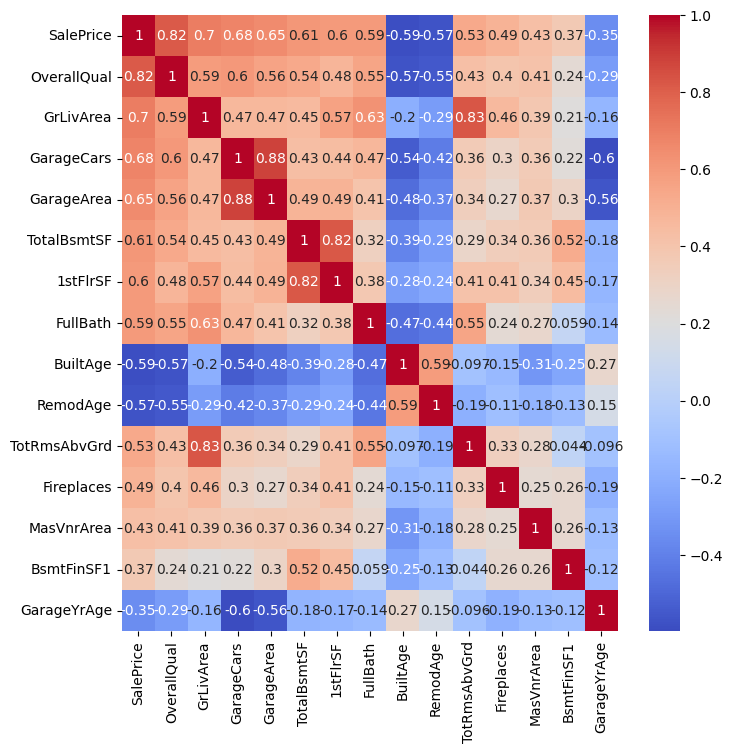

In [21]:
plt.figure(figsize=(8, 8))

sns.heatmap(
    train_data[top_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

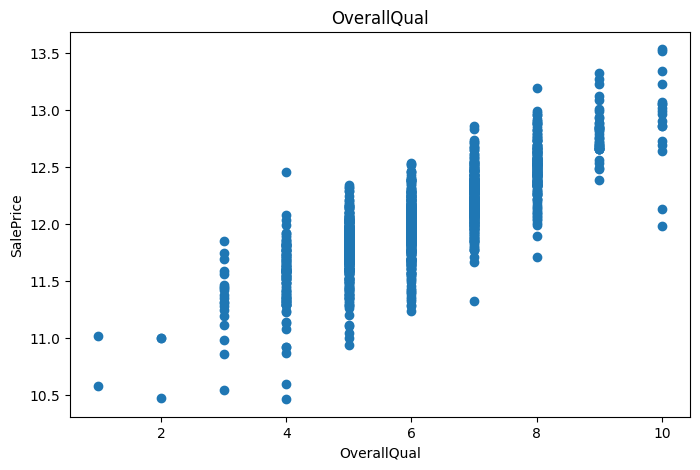

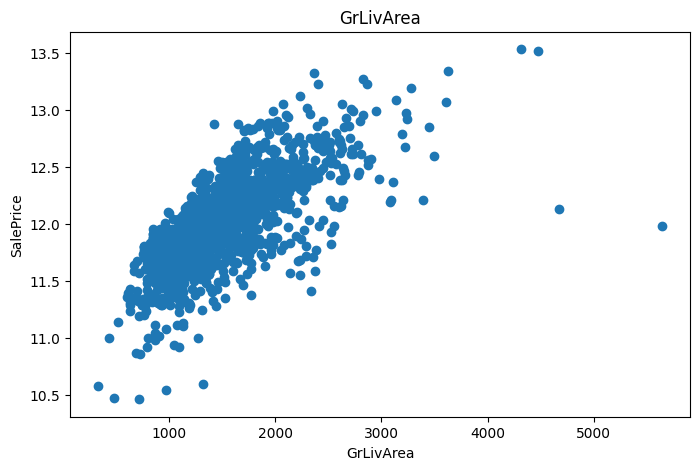

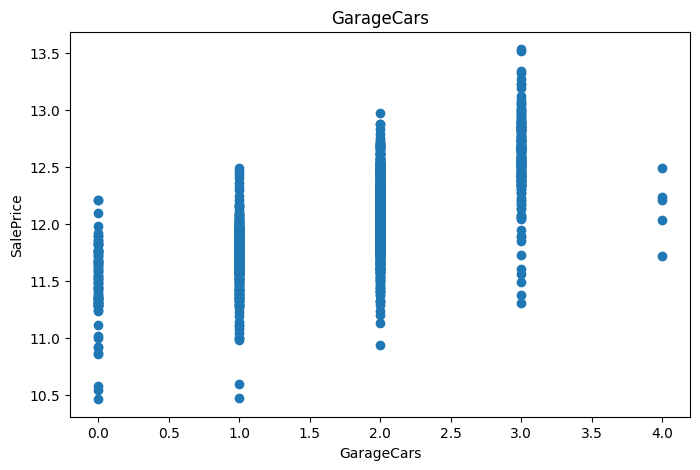

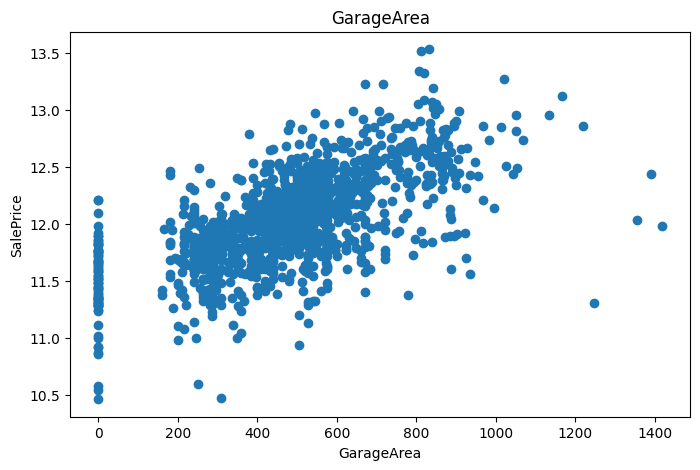

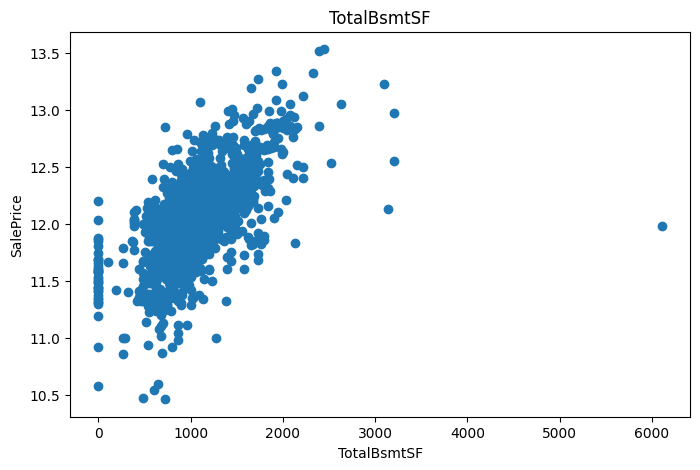

In [22]:
top_5_correlated = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

for feature in top_5_correlated:
    plt.figure(figsize=(8, 5))

    plt.scatter(
        train_data[feature],
        train_data['SalePrice']
    )
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel('SalePrice')
    plt.show()



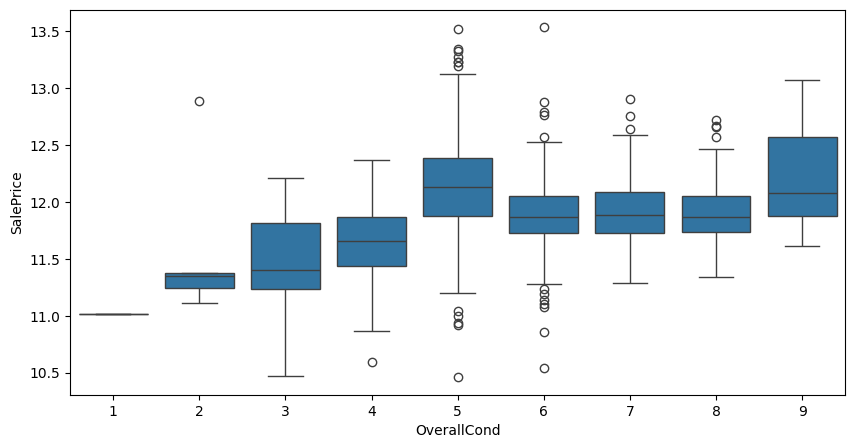

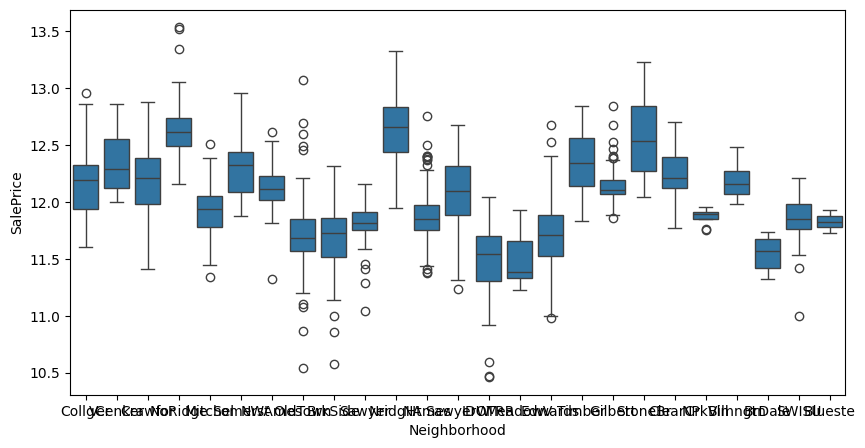

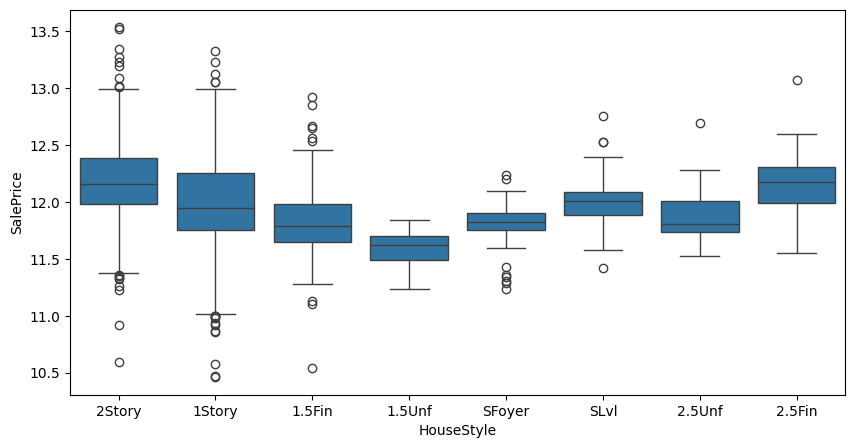

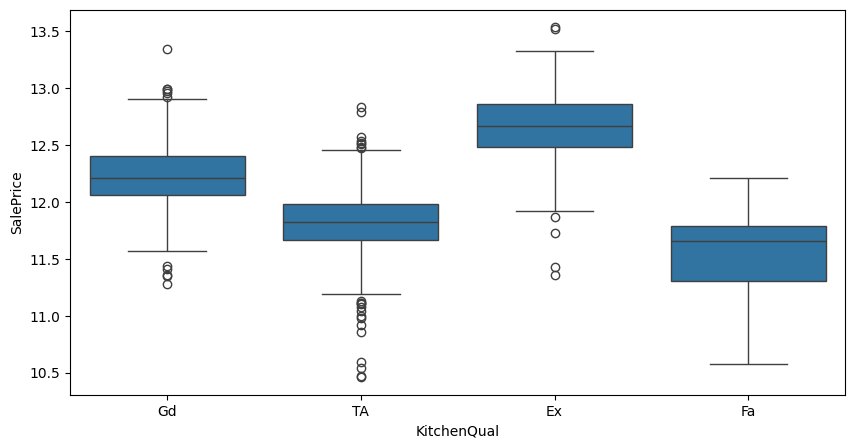

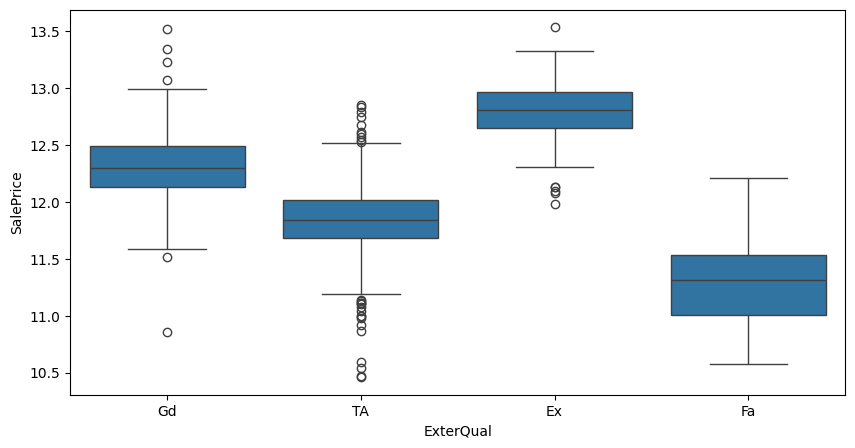

In [23]:
cat_top_features = ['OverallCond', 'Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual']

for feature in cat_top_features:
    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=feature,
        y="SalePrice",
        data=train_data
    )
plt.show()

In [24]:
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}
lot_map = {
    "Reg": 0,
    "IR1": 1,
    "IR2": 2,
    "IR3": 3
}
LandSlope_map = {
    "Sev": 0,
    "Mod": 1,
    "Gtl": 2
}
bsmt_exp_mapping = {
    "None": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

bsmt_fin_type_map = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6

}

functional_map = {
    "Sal": 0,
    "Sev": 1,
    "Maj2": 2,
    "Maj1": 3,
    "Mod": 4,
    "Min2": 5,
    "Min1": 6,
    "Typ": 7
}

garage_fin_map = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}
paved_drive_map = {
    'N': 0, 
    'P': 1,
    'Y': 2
}


train_data['KitchenQual'] = train_data['KitchenQual'].map(quality_map)
train_data['ExterQual'] = train_data['ExterQual'].map(quality_map)

train_data['ExterCond'] = train_data['ExterCond'].map(quality_map)
train_data['BsmtQual'] = train_data['BsmtQual'].map(quality_map)
train_data['BsmtCond'] = train_data['BsmtCond'].map(quality_map)
train_data['HeatingQC'] = train_data['HeatingQC'].map(quality_map)
train_data['GarageQual'] = train_data['GarageQual'].map(quality_map)
train_data['GarageCond'] = train_data['GarageCond'].map(quality_map)



train_data['LotShape'] = train_data['LotShape'].map(lot_map)
train_data['LandSlope'] = train_data['LandSlope'].map(LandSlope_map)

train_data['BsmtExposure'] = train_data['BsmtExposure'].map(bsmt_exp_mapping)

train_data['BsmtFinType1'] = train_data['BsmtFinType1'].map(bsmt_fin_type_map)
train_data['BsmtFinType2'] = train_data['BsmtFinType2'].map(bsmt_fin_type_map)
train_data['Functional'] = train_data['Functional'].map(functional_map)
train_data['GarageFinish'] = train_data['GarageFinish'].map(garage_fin_map)
train_data['PavedDrive'] = train_data['PavedDrive'].map(paved_drive_map)



In [25]:
train_data['GarageFinish'].describe()

count    1460.000000
mean        1.715753
std         0.892831
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: GarageFinish, dtype: float64

In [26]:
print(f"len of col = {len(train_data.columns)}")
train_data = pd.get_dummies(train_data, columns=['Neighborhood', 'HouseStyle', 'MSZoning', 'Street', \
    'LandContour', 'Utilities', 'LotConfig', 'Condition1', 'Condition2', 'BldgType', 'RoofStyle', 'RoofMatl', \
        'Exterior1st', 'Exterior2nd', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition'], drop_first=True)
print(f"len of col = {len(train_data.columns)}")


len of col = 74
len of col = 191


In [27]:
print(
    train_data.select_dtypes(include="object").columns
)

Index([], dtype='object')


In [28]:
X_baseline = train_data.drop(columns =['SalePrice'])

In [29]:
# train_data["TotalPorchSF"] = (
#     train_data["WoodDeckSF"] +
#     train_data["OpenPorchSF"] +
#     train_data["EnclosedPorch"] +
#     train_data["3SsnPorch"] +
#     train_data["ScreenPorch"]
# )

# train_data["HasPorch"] = (
#     train_data["TotalPorchSF"] > 0
# ).astype(int)

# # print(len(train_data.columns))
# train_data = train_data.drop(['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'], axis=1)
# # print(len(train_data.columns))


# # GarageAreaPerCar = GarageArea / GarageCars
# # print(train_data[["GarageCars", "GarageArea"]].corr()) # correlation is < 0.9 (0.88) don't think it is adding too much information 
# train_data['GarageAreaPerCar'] = train_data['GarageArea']/train_data['GarageCars']
# train_data['GarageAreaPerCar'] = train_data['GarageAreaPerCar'].fillna(0)
# train_data = train_data.drop(['GarageCars', 'GarageArea'], axis=1)


# train_data["Qual_LivArea"] = (
#     train_data["OverallQual"] *
#     train_data["GrLivArea"]
# )
# print(train_data[["OverallQual", "GrLivArea", "Qual_LivArea"]].corr())
# train_data = train_data.drop(['OverallQual', 'GrLivArea'], axis=1)

Experiment: Added interaction feature Qual_LivArea = OverallQual × GrLivArea.

Observation:

Training R² improved from 0.916 → 0.925.
Cross-validation R² decreased from 0.700 → 0.608.

Conclusion:

The interaction feature increased model complexity but reduced generalization. It likely introduced redundancy with OverallQual and GrLivArea, leading to overfitting. The feature was removed.

In [30]:
# lets build base line model

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [31]:
X = train_data.drop(columns =['SalePrice'])
y = train_data['SalePrice']


In [32]:
print(y.shape)
print(X.shape)

(1460,)
(1460, 190)


In [33]:
model = LinearRegression()
model.fit(X_baseline, y)

print(model.score(X_baseline, y))

0.938017069599181


In [34]:
model.fit(X, y)

print(model.score(X, y))

0.938017069599181


In [35]:
# X.isna().sum()
# X.loc[X['GarageAreaPerCar'].isnull(), ['GarageArea', 'GarageCars']]


In [36]:
model = LinearRegression()
model.fit(X, y)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
).to_string())

                   Feature  Coefficient
121       RoofMatl_Membran     2.700541
126       RoofMatl_WdShngl     2.588534
122         RoofMatl_Metal     2.519865
120       RoofMatl_CompShg     2.484745
123          RoofMatl_Roll     2.479082
124       RoofMatl_Tar&Grv     2.478607
125       RoofMatl_WdShake     2.402452
107        Condition2_PosN    -0.810296
176        GarageType_None    -0.598495
83             MSZoning_FV     0.423225
84             MSZoning_RH     0.420332
85             MSZoning_RL     0.411670
86             MSZoning_RM     0.379670
108        Condition2_RRAe    -0.307276
128    Exterior1st_BrkComm    -0.281370
91        Utilities_NoSeWa    -0.259970
106        Condition2_PosA     0.239466
119         RoofStyle_Shed     0.237301
165           Heating_Wall     0.206949
162           Heating_GasW     0.195175
61    Neighborhood_MeadowV    -0.165234
182           SaleType_New     0.150531
73    Neighborhood_StoneBr     0.137404
179         SaleType_ConLD     0.123117


In [37]:

model = LinearRegression()

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print(scores)
print(f"r2 score = {np.mean(scores)}")
print(f"std = {np.std(scores)}")

[0.78835907 0.90174123 0.66091243 0.87478715 0.75999516]
r2 score = 0.7971590065810732
std = 0.08600614889477197


#2
[0.6448982 0.89708834 0.44977031 0.8105352 0.5881565 ] r2 score = 0.6780897083100909 std = 0.15926180498266074

#3
[0.68998812 0.87914184 0.50153919 0.81621231 0.61213847] r2 score = 0.6998039872504037 std = 0.1362376508335766

# without any new features
[0.68998812 0.87914184 0.50153919 0.81621231 0.61213847]
r2 score = 0.6998039872504037
std = 0.1362376508335766

#4 with new features TotalPorchSF, hasporch

[0.68998812 0.87914184 0.50153919 0.81621231 0.61213847]
r2 score = 0.6998039872504037
std = 0.1362376508335766

# with new feature but dropped base columns
[0.68965199 0.88014524 0.50156427 0.8159921  0.60665828]
r2 score = 0.6988023788609729
std = 0.13718294343870444

# with new feature related to garage, 
[0.68886218 0.88085342 0.48842838 0.80926607 0.60079658]
r2 score = 0.6936413273707852
std = 0.14083521540183613

# with new feature related to garage and remvoing total porchsf and hasporch realted all new fetures
[0.68899366 0.87930547 0.48833747 0.81000452 0.60580072]
r2 score = 0.6944883694437239
std = 0.13992513926506145

# remve all above new features and adding new one quallive area
[0.63799272 0.91691993 0.23293246 0.75144578 0.50019191]
r2 score = 0.6078965592175892
std = 0.23203705376841102

# remve all above new features and adding new one quallive area, after removing core columns ('OverallQual', 'GrLivArea')
[0.67024745 0.90637704 0.39512537 0.79744358 0.55681002]
r2 score = 0.6652006906957151
std = 0.17909154157534724

In [38]:
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1))
])
# model = Ridge()

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print(scores)
print(f"r2 score = {np.mean(scores)}")
print(f"std = {np.std(scores)}")

[0.80111593 0.90243651 0.66453815 0.87629833 0.77980788]
r2 score = 0.8048393611452536
std = 0.08361394176547426


In [39]:


alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:
    model = Ridge(alpha= alpha)

    cv = KFold(
        n_splits=5,
        shuffle=True,
        # n_repeats=10,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='r2'
    )
    print(cv)
    print(alpha)
    print(scores)
    print(f"r2 score = {np.mean(scores)}")
    print(f"std = {np.std(scores)}")

KFold(n_splits=5, random_state=42, shuffle=True)
0.01
[0.81939419 0.90070612 0.66085942 0.87867807 0.79459883]
r2 score = 0.810847325220146
std = 0.08427223475626225
KFold(n_splits=5, random_state=42, shuffle=True)
0.1
[0.89313966 0.89327626 0.66176662 0.88759186 0.87911931]
r2 score = 0.8429787426299453
std = 0.09075269955549908
KFold(n_splits=5, random_state=42, shuffle=True)
1
[0.90799629 0.88937342 0.66391486 0.90118291 0.89844811]
r2 score = 0.8521831202146359
std = 0.0943234815744281
KFold(n_splits=5, random_state=42, shuffle=True)
10
[0.90221468 0.89621848 0.65275631 0.90835758 0.89879629]
r2 score = 0.8516686685797843
std = 0.0995392976080871
KFold(n_splits=5, random_state=42, shuffle=True)
100
[0.89539639 0.90006813 0.6211329  0.90408377 0.90115425]
r2 score = 0.844367089071206
std = 0.11165210485790465


In [40]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = LinearRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

In [41]:
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# r2 = r2_score(y_test, y_pred)


# print(f"rmse = {rmse}")
# print(f"r2 score = {r2}")